### Step 1: Importing necessary libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Resuable Function for Binary Cross Entropy Loss

In [6]:
def binary_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Implement BCE formula
    n = len(y_true)
    loss = -(1/n) * np.sum(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return loss

In [7]:
def simulate_training_epochs(y_true, n_epochs=10):
    n_samples = len(y_true)
    losses = []
    epochs_list = list(range(1, n_epochs + 1))
    predictions_history = []
    
    print(f"Simulating {n_epochs} epochs of training...")
    print(f"Number of samples: {n_samples}")
    print(f"True labels: {y_true}\n")
    
    for epoch in range(1, n_epochs + 1):
        if epoch == 1:
            y_pred = np.random.uniform(0.3, 0.7, n_samples)
        else:
            improvement_factor = min(0.9, epoch / n_epochs)
            y_pred = y_true * (1 - (1-improvement_factor) * np.random.uniform(0, 0.5, n_samples))
            y_pred = y_pred + (1 - y_true) * (improvement_factor * np.random.uniform(0, 0.5, n_samples))
            y_pred = np.clip(y_pred, 0.01, 0.99)
        
        predictions_history.append(y_pred)
        
        loss = binary_cross_entropy_loss(y_true, y_pred)
        losses.append(loss)
        
        # Print progress
        print(f"Epoch {epoch:2d}: Loss = {loss:.6f}")
        if epoch <= 3:
            print(f"        Predictions: {[f'{p:.3f}' for p in y_pred]}\n")
    
    return epochs_list, losses, predictions_history


In [8]:
def plot_loss_tracking(epochs, losses, y_true, predictions_history):
    # Creating figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Loss vs Epochs (Performance Measurement)
    ax1.plot(epochs, losses, 'bo-', linewidth=2, markersize=8, markeredgecolor='black')
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Training Progress: Loss Decrease Over Time', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(epochs) + 1)
    
    # Adding value labels on points
    for i, loss in enumerate(losses):
        ax1.annotate(f'{loss:.4f}', (epochs[i], loss), 
                    textcoords="offset points", xytext=(0, 10), ha='center')
    
    # Plot 2: Prediction drift over epochs (visualizing improvement)
    for sample_idx in range(len(y_true)):
        predictions_over_time = [pred[sample_idx] for pred in predictions_history]
        label_status = f"Sample {sample_idx+1} (True={y_true[sample_idx]})"
        color = 'green' if y_true[sample_idx] == 1 else 'red'
        ax2.plot(epochs, predictions_over_time, 'o-', color=color, alpha=0.7, label=label_status)
    
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision Boundary')
    ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Convergence Toward True Labels', fontsize=14, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.05, 1.05)
    
    plt.tight_layout()
    plt.show()


### Testing the loss function tracking

BINARY CROSS-ENTROPY LOSS TRACKING

Step 1: Data Simulation Complete
y_true (actual labels): [1 0 1 0 1]
Simulating 10 epochs of training...
Number of samples: 5
True labels: [1 0 1 0 1]

Epoch  1: Loss = 0.850499
        Predictions: ['0.450', '0.680', '0.593', '0.539', '0.362']

Epoch  2: Loss = 0.189256
        Predictions: ['0.938', '0.097', '0.654', '0.021', '0.717']

Epoch  3: Loss = 0.090890
        Predictions: ['0.936', '0.021', '0.816', '0.055', '0.898']

Epoch  4: Loss = 0.139067
Epoch  5: Loss = 0.151425
Epoch  6: Loss = 0.173381
Epoch  7: Loss = 0.092372
Epoch  8: Loss = 0.144189
Epoch  9: Loss = 0.083085
Epoch 10: Loss = 0.150176

Step 4: Generating Visualization


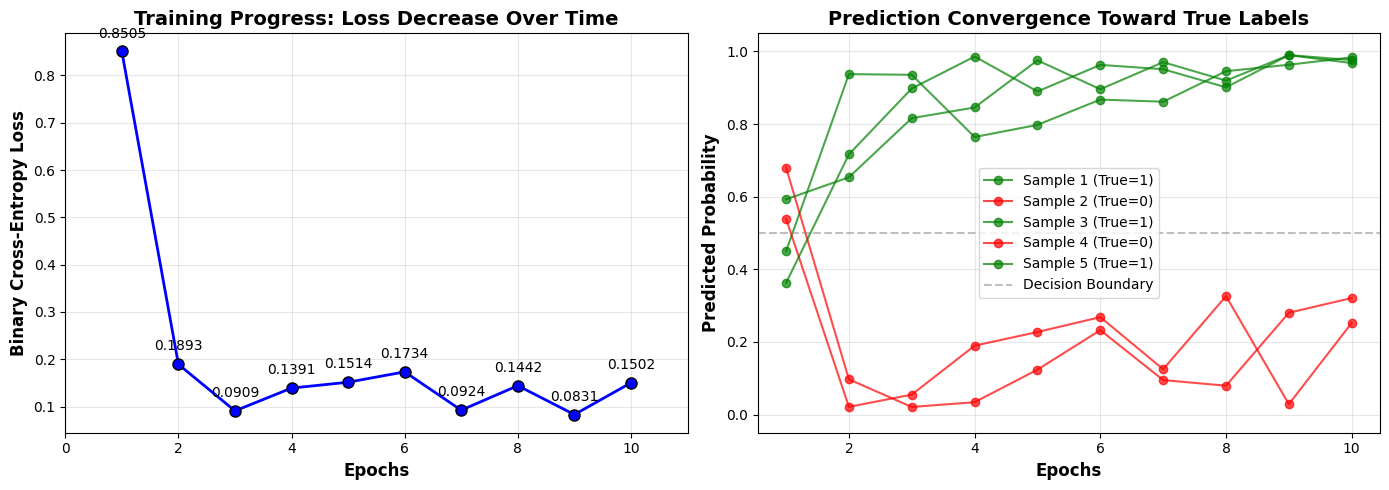


TRAINING SUMMARY
Initial Loss (Epoch 1): 0.850499
Final Loss (Epoch 10): 0.150176
Improvement: 82.34% reduction


In [12]:
print("="*40)
print("BINARY CROSS-ENTROPY LOSS TRACKING")
print("="*40)

# Data Simulation - Create y_true and initial y_pred
np.random.seed(42)  # For reproducibility
n_samples = 5
y_true = np.array([1, 0, 1, 0, 1])
print(f"\nStep 1: Data Simulation Complete")
print(f"y_true (actual labels): {y_true}")

# Simulate 10 training epochs with improving predictions
epochs, losses, pred_history = simulate_training_epochs(y_true, n_epochs=10)

# Visualization
print("\n" + "="*60)
print("Step 4: Generating Visualization")
print("="*60)
plot_loss_tracking(epochs, losses, y_true, pred_history)

# Additional analysis
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Initial Loss (Epoch 1): {losses[0]:.6f}")
print(f"Final Loss (Epoch 10): {losses[-1]:.6f}")
print(f"Improvement: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}% reduction")